# 05 — India Market & Sector

**Chain position:** Macro → Risk → Rates → Global Equity → `India` → Companies

Notebook 04 answered *should I be in India?* This one answers **where in India?**

The data here comes from NSE's own `allIndices` endpoint, which carries all 139 indices
with **official PE, PB and dividend yield**, advances/declines breadth, 52-week ranges,
and 30-day and 365-day returns. That matters: Yahoo's Indian sector indices were tested
for this project and rejected — roughly 55% of the series were missing. Using the
exchange's own numbers means the valuations here are the ones NSE publishes, not a
third-party reconstruction.

Sectors are selected by the endpoint's own `key` category rather than a hardcoded list,
so when NSE adds an index it appears automatically instead of being silently absent.

### One limitation, stated plainly

NSE's FII/DII endpoint returns **only the most recent session.** There is no history
API — `?date=` is ignored and `/api/historical/` returns 503/404, both verified. So the
cumulative-flow overlay cannot be reconstructed retrospectively. Instead, every run of
this project appends the day's snapshot to `data/fii_dii_history.csv`, and the flow
section below reports exactly how many days have accumulated. On a fresh clone that is
one row; it becomes a real series with use.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_root = Path.cwd()
while not (_root / "mkt").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mkt
from mkt import (config, cache, fetch, align, dashboard,
                 indicators as ind, fundamentals as fnd, score, viz)

# Set REFRESH = True to force a live re-fetch of every source, ignoring the cache.
REFRESH = False
mkt.bootstrap(refresh=REFRESH)

mkt v1.0.0 | run 2026-09-09 10:47 | REFRESH=False | cache=G:\stock market analysis\data\cache


## 1. Market state and freshness

In [2]:
status = fetch.nse_market_status()
display(status[["market", "marketStatus", "tradeDate", "index", "last", "percentChange"]])

idx = fetch.nse_all_indices()
print(f"\nNSE allIndices: {len(idx)} indices across {idx['key'].nunique()} categories")
print(f"Exchange timestamp: {idx.attrs['as_of']}")
display(idx["key"].value_counts().to_frame("indices"))

,market,marketStatus,tradeDate,index,last,percentChange
0,Capital Market,Open,09-Sep-2026 10:44,NIFTY 50,"23,509.30",-0.53
1,Currency,Open,09-Sep-2026,,,
2,Commodity,Open,09-Sep-2026,,,
3,Debt,Open,09-Sep-2026,,,
4,NaN,NaN,NaN,NIFTY50 USD,"8,561.85",-0.86
5,currencyfuture,Open,09-Sep-2026,,95.1800,



NSE allIndices: 139 indices across 6 categories
Exchange timestamp: 2026-09-09 10:41:00


,indices
key,
STRATEGY INDICES,42
THEMATIC INDICES,41
SECTORAL INDICES,21
BROAD MARKET INDICES,18
FIXED INCOME INDICES,11
INDICES ELIGIBLE IN DERIVATIVES,6


## 2. The market-cap curve

Large, mid, small and micro caps do not move together, and the spread between them is
one of the cleanest risk-appetite reads available in India. Small caps leading is a
late-cycle, high-risk-appetite signature; large caps leading is defensive rotation.

,last,percentChange,perChange30d,perChange365d,pe,pb,dy
index,,,,,,,
NIFTY 50,"23,505.80",-0.55,-4.33,-5.48,19.98,2.86,1.20
NIFTY NEXT 50,"72,825.90",-0.17,-2.51,7.95,19.28,3.25,0.99
NIFTY 100,"24,685.80",-0.48,-3.99,-3.15,19.85,2.92,1.16
NIFTY MIDCAP 100,"62,522.70",-0.62,-1.48,8.80,30.32,4.33,0.54
NIFTY SMALLCAP 100,"20,031.70",-0.51,0.82,12.89,31.89,3.56,0.55
NIFTY 500,"22,991.90",-0.49,-3.04,0.19,22.39,3.21,0.97
NIFTY MICROCAP 250,"26,611.15",-0.39,2.13,12.26,28.73,3.58,0.43


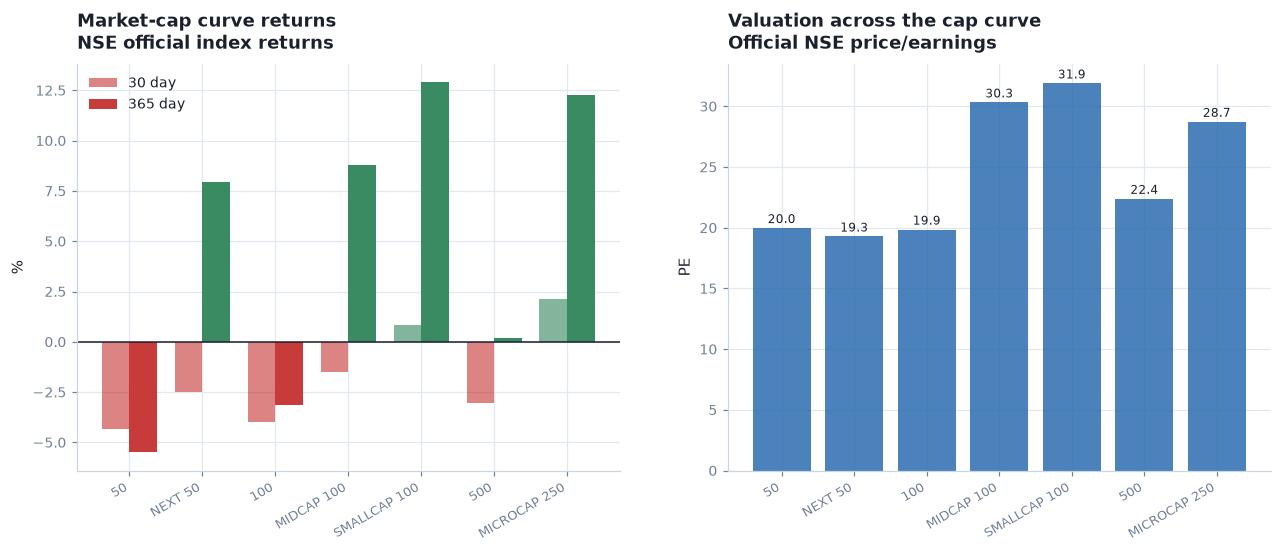

Smallcap minus largecap, 365 days: +18.4 pp (small caps leading -- risk appetite on)


In [3]:
broad = idx[idx["index"].isin(config.INDIA_BROAD_INDICES)].set_index("index")
missing_broad = set(config.INDIA_BROAD_INDICES) - set(broad.index)
if missing_broad:
    print("Not carried by NSE today (reported, not hidden):", sorted(missing_broad))

cap_cols = ["last", "percentChange", "perChange30d", "perChange365d", "pe", "pb", "dy"]
cap = broad[cap_cols].reindex([c for c in config.INDIA_BROAD_INDICES if c in broad.index])
display(cap.round(2))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.8))
w = 0.38
xs = np.arange(len(cap))
a1.bar(xs - w/2, cap["perChange30d"], w, label="30 day",
       color=[viz.POS if v >= 0 else viz.NEG for v in cap["perChange30d"]], alpha=0.6)
a1.bar(xs + w/2, cap["perChange365d"], w, label="365 day",
       color=[viz.POS if v >= 0 else viz.NEG for v in cap["perChange365d"]], alpha=0.95)
a1.set_xticks(xs); a1.set_xticklabels([c.replace("NIFTY ", "") for c in cap.index],
                                      rotation=30, ha="right", fontsize=8.5)
a1.axhline(0, color=viz.INK, lw=1)
viz.title(a1, "Market-cap curve returns", "NSE official index returns")
a1.set_ylabel("%"); a1.legend()

a2.bar(xs, cap["pe"], color=viz.PALETTE[0], alpha=0.85)
a2.set_xticks(xs); a2.set_xticklabels([c.replace("NIFTY ", "") for c in cap.index],
                                      rotation=30, ha="right", fontsize=8.5)
for i, v in enumerate(cap["pe"]):
    if np.isfinite(v) and v > 0:
        a2.text(i, v + 0.4, f"{v:.1f}", ha="center", fontsize=8)
viz.title(a2, "Valuation across the cap curve", "Official NSE price/earnings")
a2.set_ylabel("PE")
viz.save(fig, "05_cap_curve"); plt.show()

if {"NIFTY 50", "NIFTY SMALLCAP 100"} <= set(cap.index):
    spread = float(cap.loc["NIFTY SMALLCAP 100", "perChange365d"]
                   - cap.loc["NIFTY 50", "perChange365d"])
    print(f"Smallcap minus largecap, 365 days: {spread:+.1f} pp "
          f"({'small caps leading -- risk appetite on' if spread > 0 else 'large caps leading -- defensive'})")

## 3. Sector rotation quadrant

The core view. Each sector is plotted on **365-day return (long-run trend)** against
**30-day return (near-term momentum)**, both relative to the Nifty 50 so the market's own
move is netted out.

| Quadrant | Meaning |
|---|---|
| **Leading** | Beating the index over both windows — established strength |
| **Improving** | Lagging over a year but beating recently — the turn candidates |
| **Lagging** | Behind on both — value traps or broken sectors |
| **Weakening** | Ahead over a year but losing recently — where distribution shows up first |

For a swing/positional horizon, *Improving* and *Weakening* carry the most information:
they are where the rotation is actually happening.

34 sector + thematic indices, measured against NIFTY 50 (30d -4.33%, 365d -5.48%)


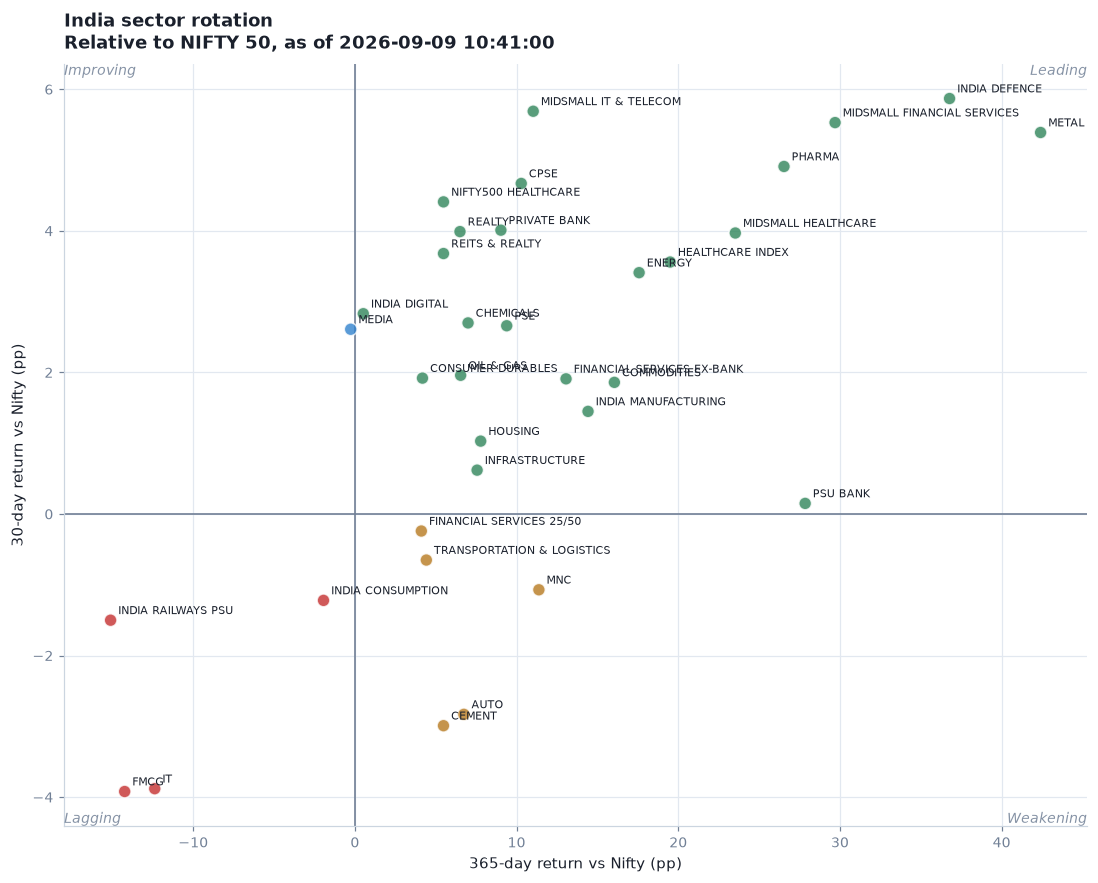

In [4]:
sectors = fetch.nse_by_category(config.NSE_CATEGORIES["sector"], idx)
thematic = idx[idx["index"].isin(config.INDIA_THEMATIC_EXTRA)]
sect = (pd.concat([sectors, thematic])
        .drop_duplicates(subset="index")
        .set_index("index"))
sect = sect[sect["last"] > 0]

nifty_row = fetch.nse_index_row(config.NIFTY_INDEX_NAME, idx)
n30, n365 = float(nifty_row["perChange30d"]), float(nifty_row["perChange365d"])
n_pe, n_pb, n_dy = float(nifty_row["pe"]), float(nifty_row["pb"]), float(nifty_row["dy"])

sect["rel_30d"] = sect["perChange30d"] - n30
sect["rel_365d"] = sect["perChange365d"] - n365
print(f"{len(sect)} sector + thematic indices, measured against "
      f"{config.NIFTY_INDEX_NAME} (30d {n30:+.2f}%, 365d {n365:+.2f}%)")

fig, ax = plt.subplots(figsize=(12, 9))
viz.quadrant(sect["rel_365d"], sect["rel_30d"], ax=ax,
             labels=[c.replace("NIFTY ", "") for c in sect.index],
             title_="India sector rotation",
             sub=f"Relative to {config.NIFTY_INDEX_NAME}, as of {idx.attrs['as_of']}",
             xlabel="365-day return vs Nifty (pp)",
             ylabel="30-day return vs Nifty (pp)",
             quad_names=("Leading", "Improving", "Lagging", "Weakening"))
viz.save(fig, "05_sector_rotation"); plt.show()

In [5]:
def quad_of(r):
    if r["rel_365d"] >= 0 and r["rel_30d"] >= 0:
        return "Leading"
    if r["rel_365d"] < 0 and r["rel_30d"] >= 0:
        return "Improving"
    if r["rel_365d"] < 0 and r["rel_30d"] < 0:
        return "Lagging"
    return "Weakening"

sect["quadrant"] = sect.apply(quad_of, axis=1)
display(sect["quadrant"].value_counts().to_frame("sectors"))
for q in ["Leading", "Improving", "Weakening", "Lagging"]:
    members = sect[sect["quadrant"] == q].sort_values("rel_30d", ascending=False)
    print(f"\n{q} ({len(members)}):")
    for name, r in members.iterrows():
        print(f"   {name.replace('NIFTY ',''):32s} 365d {r['rel_365d']:+7.1f}pp   30d {r['rel_30d']:+6.1f}pp")

,sectors
quadrant,
Leading,24
Weakening,5
Lagging,4
Improving,1



Leading (24):
   INDIA DEFENCE                    365d   +36.8pp   30d   +5.9pp
   MIDSMALL IT & TELECOM            365d   +11.0pp   30d   +5.7pp
   MIDSMALL FINANCIAL SERVICES      365d   +29.7pp   30d   +5.5pp
   METAL                            365d   +42.4pp   30d   +5.4pp
   PHARMA                           365d   +26.5pp   30d   +4.9pp
   CPSE                             365d   +10.3pp   30d   +4.7pp
   NIFTY500 HEALTHCARE              365d    +5.5pp   30d   +4.4pp
   PRIVATE BANK                     365d    +9.0pp   30d   +4.0pp
   REALTY                           365d    +6.5pp   30d   +4.0pp
   MIDSMALL HEALTHCARE              365d   +23.5pp   30d   +4.0pp
   REITS & REALTY                   365d    +5.5pp   30d   +3.7pp
   HEALTHCARE INDEX                 365d   +19.5pp   30d   +3.6pp
   ENERGY                           365d   +17.6pp   30d   +3.4pp
   INDIA DIGITAL                    365d    +0.5pp   30d   +2.8pp
   CHEMICALS                        365d    +7.0pp   30d   +2

## 4. Valuation heatmap

NSE's own PE, PB and dividend yield per sector, expressed as a **premium or discount to
the Nifty 50**. This is the check on the rotation view: a sector can be Leading and
still be the wrong entry if it is already at a 60% valuation premium.

Sectors reporting a zero or absent PE (common for indices with loss-making constituents)
are shown as blank rather than as zero.

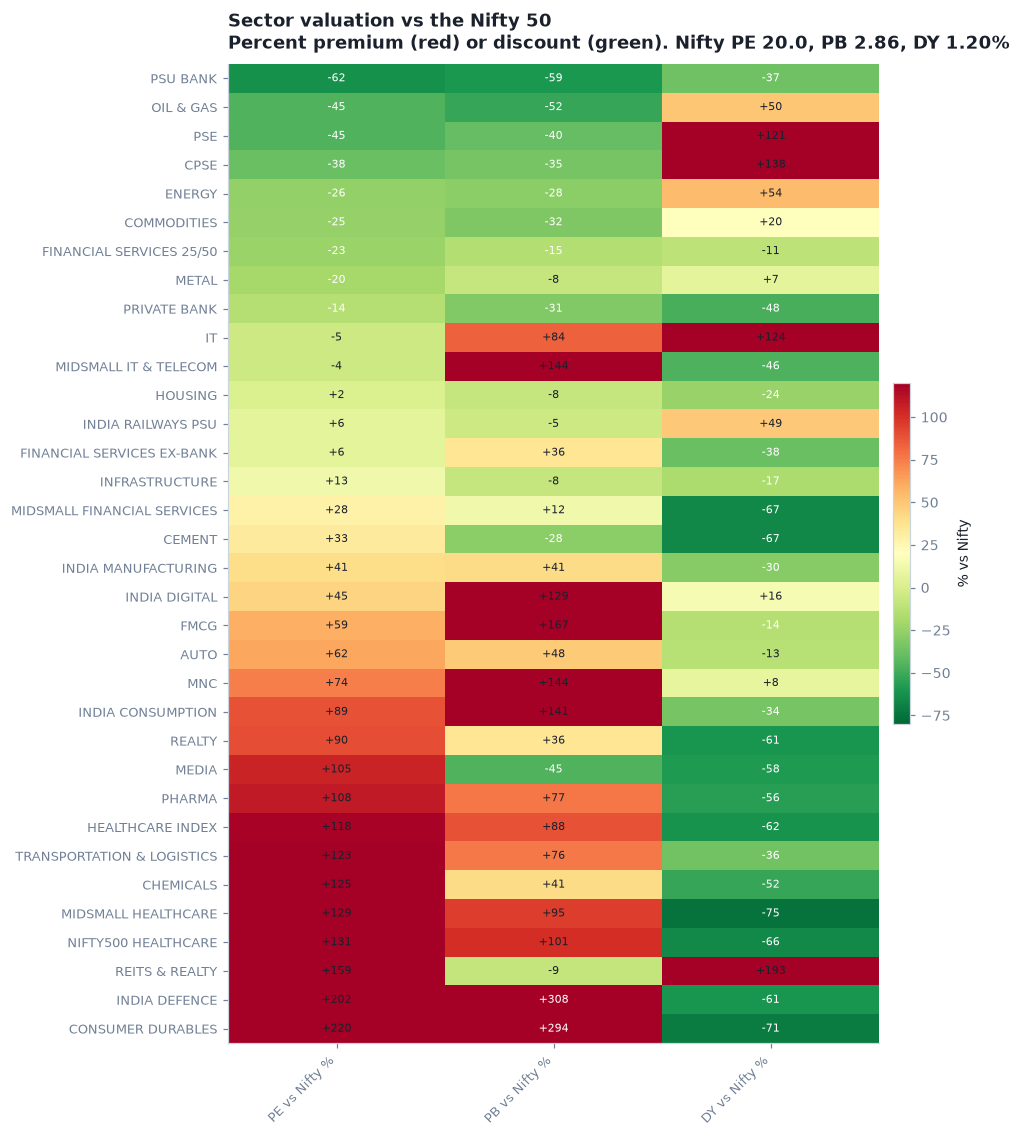

,pe,pb,dy,PE vs Nifty %,PB vs Nifty %
index,,,,,
NIFTY PSU BANK,7.57,1.16,0.76,-62.11,-59.44
NIFTY OIL & GAS,10.94,1.36,1.80,-45.25,-52.45
NIFTY PSE,11.02,1.73,2.65,-44.84,-39.51
NIFTY CPSE,12.42,1.87,2.85,-37.84,-34.62
NIFTY ENERGY,14.78,2.06,1.85,-26.03,-27.97
NIFTY COMMODITIES,14.99,1.94,1.44,-24.97,-32.17
NIFTY FINANCIAL SERVICES 25/50,15.38,2.43,1.07,-23.02,-15.03
NIFTY METAL,16.02,2.63,1.28,-19.82,-8.04
NIFTY PRIVATE BANK,17.11,1.97,0.63,-14.36,-31.12


In [6]:
val = sect[["pe", "pb", "dy"]].replace(0, np.nan).dropna(how="all").copy()
val["PE vs Nifty %"] = (val["pe"] / n_pe - 1) * 100
val["PB vs Nifty %"] = (val["pb"] / n_pb - 1) * 100
val["DY vs Nifty %"] = (val["dy"] / n_dy - 1) * 100 if n_dy else np.nan

heat = val[["PE vs Nifty %", "PB vs Nifty %", "DY vs Nifty %"]].dropna(how="all")
heat = heat.sort_values("PE vs Nifty %")
heat.index = [c.replace("NIFTY ", "") for c in heat.index]

fig, ax = plt.subplots(figsize=(8, max(5, 0.34 * len(heat))))
viz.heatmap(heat, ax=ax, cmap="RdYlGn_r", fmt="{:+.0f}", vmin=-80, vmax=120,
            title_="Sector valuation vs the Nifty 50",
            sub=f"Percent premium (red) or discount (green). Nifty PE {n_pe:.1f}, "
                f"PB {n_pb:.2f}, DY {n_dy:.2f}%",
            cbar_label="% vs Nifty")
viz.save(fig, "05_valuation_heatmap"); plt.show()

display(val[["pe", "pb", "dy", "PE vs Nifty %", "PB vs Nifty %"]]
        .sort_values("PE vs Nifty %").round(2))

## 5. Market breadth

Two independent reads:

- **Advances/declines** inside each index today — the intraday breadth snapshot NSE
  publishes directly.
- **Percent of Nifty 50 constituents above their 20/50/200-day moving averages** —
  computed from price history, and the more durable measure. A market making highs on
  narrowing breadth is being carried by a few names.

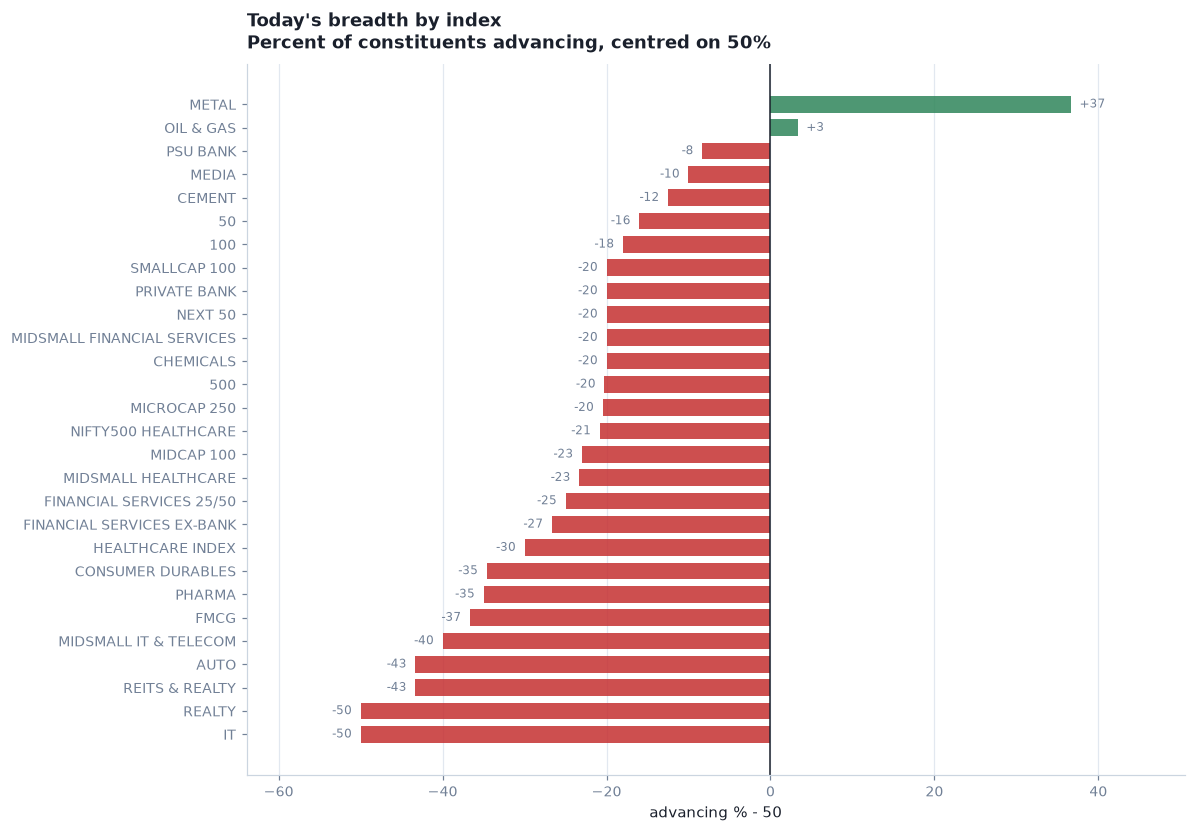

In [7]:
breadth = idx[idx["advances"].notna() & (idx["advances"] + idx["declines"] > 0)].copy()
breadth["adv_pct"] = breadth["advances"] / (breadth["advances"] + breadth["declines"]
                                            + breadth["unchanged"].fillna(0)) * 100
key_breadth = breadth[breadth["index"].isin(
    config.INDIA_BROAD_INDICES + list(sectors["index"]))].set_index("index")

fig, ax = plt.subplots(figsize=(11, max(4, 0.30 * len(key_breadth))))
s = key_breadth["adv_pct"].sort_values() - 50
s.index = [c.replace("NIFTY ", "") for c in s.index]
viz.ranked_bar(s, ax=ax, title_="Today's breadth by index",
               sub="Percent of constituents advancing, centred on 50%",
               xlabel="advancing % - 50", fmt="{:+.0f}")
viz.save(fig, "05_breadth_today"); plt.show()

  fetched 50/50 tickers in 24s


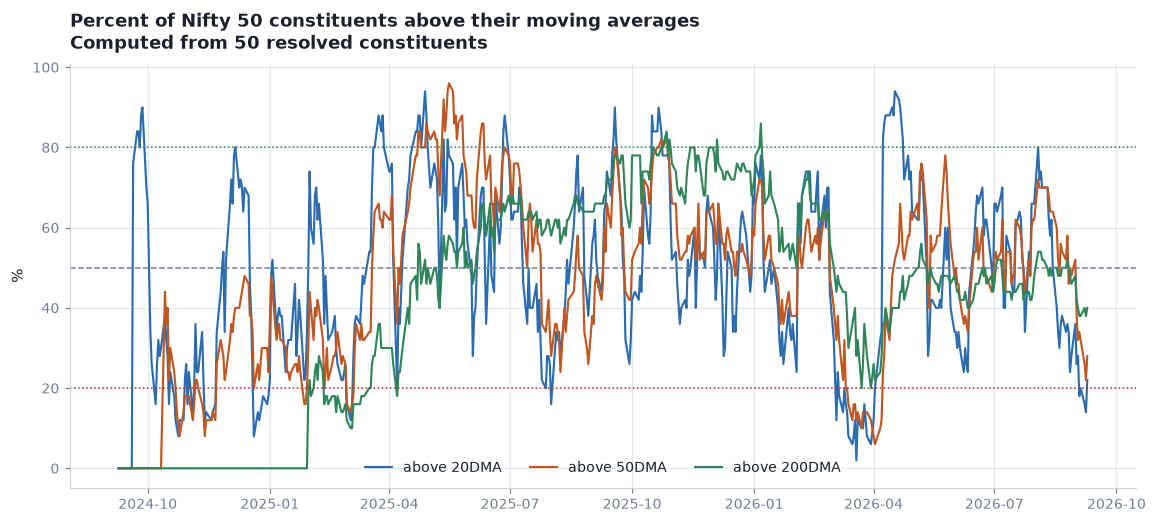

,% of constituents
above 20DMA,22.00
above 50DMA,28.00
above 200DMA,40.00


Average breadth: 30% (narrow -- few names carrying the index)


In [8]:
n50_frames, n50_failed = fetch.price_histories(
    list(config.NIFTY_50), period="2y")
if n50_failed:
    print("Dropped from the breadth calc (reported, not hidden):")
    for t, why in n50_failed:
        print(f"  - {t}: {why}")

n50_px = align.align_multi(n50_frames, calendar="NSE", max_gap=3)
align.assert_alignment(n50_px, max_nan_pct=8.0, label="nifty 50 constituents")

above = {}
for w in config.DMA_WINDOWS:
    dma = n50_px.rolling(w, min_periods=w // 2).mean()
    above[f"above {w}DMA"] = (n50_px > dma).sum(axis=1) / n50_px.notna().sum(axis=1) * 100
above = pd.DataFrame(above).dropna(how="all")

fig, ax = plt.subplots(figsize=(12.5, 5))
for c in above.columns:
    ax.plot(above.index, above[c], lw=1.4, label=c)
ax.axhline(50, color=viz.MUTED, ls="--", lw=1)
ax.axhline(80, color=viz.POS, ls=":", lw=1); ax.axhline(20, color=viz.NEG, ls=":", lw=1)
viz.title(ax, "Percent of Nifty 50 constituents above their moving averages",
          f"Computed from {n50_px.shape[1]} resolved constituents")
ax.set_ylabel("%"); ax.legend(ncol=3)
viz.save(fig, "05_breadth_dma"); plt.show()

breadth_now = above.iloc[-1]
display(breadth_now.to_frame("% of constituents").round(1))
breadth_score = float(breadth_now.mean())
print(f"Average breadth: {breadth_score:.0f}% "
      f"({'broad participation' if breadth_score > 55 else 'narrow -- few names carrying the index' if breadth_score < 45 else 'mixed'})")

## 6. India VIX

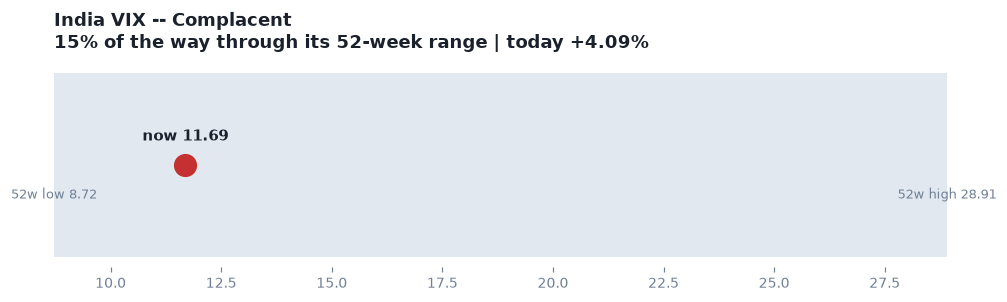

India VIX 11.69 (+4.09% today) | 52w range 8.72-28.91 | regime: Complacent


In [9]:
ivix_row = fetch.nse_index_row(config.INDIA_VIX, idx)
ivix_now = float(ivix_row["last"])
ivix_chg = float(ivix_row["percentChange"])
ivix_hi, ivix_lo = float(ivix_row["yearHigh"]), float(ivix_row["yearLow"])
pos_in_range = (ivix_now - ivix_lo) / (ivix_hi - ivix_lo) * 100 if ivix_hi > ivix_lo else np.nan

ivix_regime = ("Complacent" if pos_in_range < 25 else
               "Elevated" if pos_in_range > 70 else "Normal")

fig, ax = plt.subplots(figsize=(11, 2.4))
ax.barh([0], [ivix_hi - ivix_lo], left=[ivix_lo], color=viz.GRID, height=0.42)
ax.scatter([ivix_now], [0], s=200, color=viz.NEG, zorder=5)
ax.annotate(f"now {ivix_now:.2f}", xy=(ivix_now, 0), xytext=(0, 16),
            textcoords="offset points", ha="center", fontsize=10, weight="bold")
for v, lab in [(ivix_lo, f"52w low {ivix_lo:.2f}"), (ivix_hi, f"52w high {ivix_hi:.2f}")]:
    ax.annotate(lab, xy=(v, 0), xytext=(0, -22), textcoords="offset points",
                ha="center", fontsize=8.5, color=viz.MUTED)
ax.set_yticks([]); ax.grid(False)
for sp in ("left", "bottom"):
    ax.spines[sp].set_visible(False)
viz.title(ax, f"India VIX -- {ivix_regime}",
          f"{pos_in_range:.0f}% of the way through its 52-week range | today {ivix_chg:+.2f}%")
viz.save(fig, "05_india_vix"); plt.show()

print(f"India VIX {ivix_now:.2f} ({ivix_chg:+.2f}% today) | 52w range "
      f"{ivix_lo:.2f}-{ivix_hi:.2f} | regime: {ivix_regime}")

## 7. FII and DII flows

Foreign institutional investors and domestic institutions are frequently on opposite
sides in India, and the balance between them explains a great deal of what the index
does.

As stated at the top: NSE publishes only the latest session, so the history below is
what this project has accumulated across its own runs.

In [10]:
flows_today = fetch.nse_fii_dii()
display(flows_today[["date", "category", "buyValue", "sellValue", "netValue"]])

hist = fetch.fii_dii_history(append_latest=True)
n_days = len(hist)
print(f"\nAccumulated flow history: {n_days} session(s) in {config.FII_DII_HISTORY.name}")

if n_days >= 5:
    cum = hist.cumsum()
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(12.5, 7), sharex=True)
    for c in hist.columns:
        a1.bar(hist.index, hist[c], label=c, alpha=0.75,
               color=viz.POS if "DII" in c else viz.PALETTE[3])
    a1.axhline(0, color=viz.INK, lw=1)
    viz.title(a1, "Daily net institutional flows", "INR crore")
    a1.legend()
    for c in cum.columns:
        a2.plot(cum.index, cum[c], lw=1.6, label=f"cumulative {c}")
    a2.axhline(0, color=viz.INK, lw=1)
    viz.title(a2, "Cumulative net flows", "Since this project started recording")
    a2.legend()
    viz.save(fig, "05_fii_dii"); plt.show()
else:
    print("\nNot enough accumulated sessions to plot a cumulative overlay yet.")
    print("Re-run this notebook on subsequent trading days and the series will build.")
    print("Today's reading, in INR crore:")
    for _, r in flows_today.iterrows():
        print(f"   {r['category']:8s} net {r['netValue']:+10,.2f}  "
              f"(bought {r['buyValue']:,.2f}, sold {r['sellValue']:,.2f})")

net_today = flows_today.set_index("category")["netValue"]
fii_net = float(net_today.get("FII/FPI", np.nan))
dii_net = float(net_today.get("DII", np.nan))

,date,category,buyValue,sellValue,netValue
0,2026-09-08,DII,"14,678.53","13,328.89","1,349.64"
1,2026-09-08,FII/FPI,"11,704.84","11,828.03",-123.19



Accumulated flow history: 2 session(s) in fii_dii_history.csv

Not enough accumulated sessions to plot a cumulative overlay yet.
Re-run this notebook on subsequent trading days and the series will build.
Today's reading, in INR crore:
   DII      net  +1,349.64  (bought 14,678.53, sold 13,328.89)
   FII/FPI  net    -123.19  (bought 11,704.84, sold 11,828.03)


## 8. Ranked sector table

A composite score per sector from four inputs, each z-scored across sectors:

| Input | Weight | Direction |
|---|---|---|
| 365-day return vs Nifty | 1.2 | higher better |
| 30-day return vs Nifty | 1.0 | higher better |
| PE vs Nifty | 0.8 | **lower** better |
| Dividend yield | 0.4 | higher better |

Momentum is weighted above valuation because the horizon here is swing/positional. The
valuation leg is a brake, not the driver.

,last,perChange30d,perChange365d,rel_30d,rel_365d,pe,pb,dy,quadrant,score,coverage_%
METAL,"13,329.35",1.06,36.93,5.39,42.41,16.02,2.63,1.28,Leading,5.57,100.00
MIDSMALL FINANCIAL SERVICES,"22,562.20",1.20,24.22,5.53,29.70,25.67,3.21,0.40,Leading,4.49,100.00
PSU BANK,"8,419.10",-4.18,22.37,0.15,27.85,7.57,1.16,0.76,Leading,3.72,100.00
ENERGY,"38,392.25",-0.92,12.10,3.41,17.58,14.78,2.06,1.85,Leading,3.54,100.00
PHARMA,"26,696.90",0.58,21.06,4.91,26.54,41.62,5.05,0.53,Leading,3.39,100.00
CPSE,"6,506.80",0.34,4.81,4.67,10.29,12.42,1.87,2.85,Leading,3.19,100.00
INDIA DEFENCE,"9,881.95",1.54,31.30,5.87,36.78,60.34,11.67,0.47,Leading,3.05,100.00
COMMODITIES,"9,744.40",-2.47,10.57,1.86,16.05,14.99,1.94,1.44,Leading,2.40,100.00
PSE,"9,757.05",-1.67,3.91,2.66,9.39,11.02,1.73,2.65,Leading,2.39,100.00
MIDSMALL HEALTHCARE,"52,456.75",-0.36,18.05,3.97,23.53,45.78,5.59,0.30,Leading,2.15,100.00


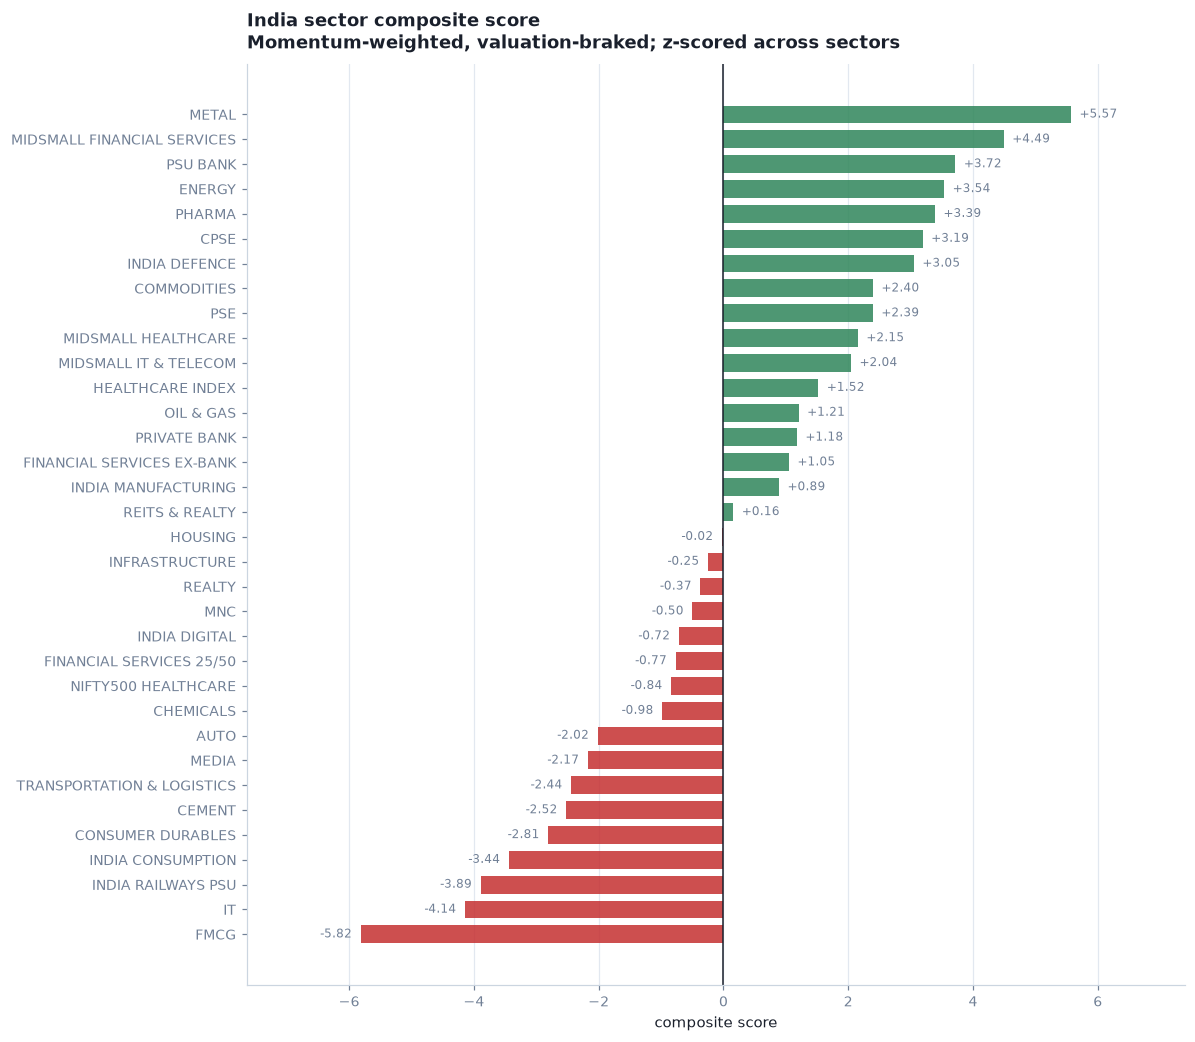

Leaders : ['METAL', 'MIDSMALL FINANCIAL SERVICES', 'PSU BANK', 'ENERGY', 'PHARMA']
Laggards: ['INDIA RAILWAYS PSU', 'IT', 'FMCG']


In [11]:
rank_df = sect.copy()
rank_df["pe_rel"] = (rank_df["pe"].replace(0, np.nan) / n_pe - 1) * 100
rank_df["dy_"] = rank_df["dy"].replace(0, np.nan)

spec = {
    "rel_365d": (1.2, +1),
    "rel_30d": (1.0, +1),
    "pe_rel": (0.8, -1),
    "dy_": (0.4, +1),
}
sector_score, contrib = score.score_block(rank_df, spec, label="sector composite")
rank_df["score"] = sector_score
rank_df["coverage_%"] = contrib["_coverage_%"]

out = (rank_df[["last", "perChange30d", "perChange365d", "rel_30d", "rel_365d",
                "pe", "pb", "dy", "quadrant", "score", "coverage_%"]]
       .sort_values("score", ascending=False))
out.index = [c.replace("NIFTY ", "") for c in out.index]
display(out.round(2))

fig, ax = plt.subplots(figsize=(11, max(4, 0.32 * len(out))))
viz.ranked_bar(out["score"], ax=ax, title_="India sector composite score",
               sub="Momentum-weighted, valuation-braked; z-scored across sectors",
               xlabel="composite score", fmt="{:+.2f}")
viz.save(fig, "05_sector_ranked"); plt.show()

top_sectors = list(out.head(5).index)
bottom_sectors = list(out.tail(3).index)
print(f"Leaders : {top_sectors}")
print(f"Laggards: {bottom_sectors}")

## 9. India signal

In [12]:
components = {
    "breadth": (breadth_score - 50) / 25,
    "cap_curve": np.clip(spread / 20, -2, 2) if "spread" in dir() else 0.0,
    "vix": -(pos_in_range - 50) / 30,
    "index_365d": np.clip(n365 / 15, -2, 2),
}
india_score = float(np.mean(list(components.values())))
india_label = ("Constructive" if india_score >= 0.4 else
               "Cautious" if india_score <= -0.4 else "Mixed")

display(pd.Series(components).to_frame("z-ish score").round(2))
print(f"INDIA MARKET SIGNAL: {india_label} ({india_score:+.2f})")
print(f"Nifty 50 {float(nifty_row['last']):,.2f} | 30d {n30:+.2f}% | 365d {n365:+.2f}% | "
      f"PE {n_pe:.1f} | breadth {breadth_score:.0f}% | India VIX {ivix_now:.2f}")

payload = {
    "signal": india_label,
    "score": round(india_score, 3),
    "as_of": str(idx.attrs["as_of"]),
    "nifty": {"level": float(nifty_row["last"]), "chg_30d_%": n30, "chg_365d_%": n365,
              "pe": n_pe, "pb": n_pb, "dy": n_dy},
    "breadth": {**{k: round(float(v), 1) for k, v in breadth_now.items()},
                "average_%": round(breadth_score, 1),
                "constituents_used": int(n50_px.shape[1])},
    "india_vix": {"level": ivix_now, "pct_of_52w_range": round(float(pos_in_range), 1),
                  "regime": ivix_regime},
    "flows_latest": {"date": str(flows_today["date"].max().date()),
                     "FII_net_cr": fii_net, "DII_net_cr": dii_net,
                     "history_days": int(n_days),
                     "note": "NSE publishes latest session only; history accumulates per run"},
    "sector_leaders": top_sectors,
    "sector_laggards": bottom_sectors,
    "sector_scores": {k: round(float(v), 3) for k, v in out["score"].items()},
    "quadrants": {k: int(v) for k, v in sect["quadrant"].value_counts().items()},
    "dropped_constituents": [t for t, _ in n50_failed],
}
dashboard.append("05_india_market", payload)
display(dashboard.summary())

,z-ish score
breadth,-0.80
cap_curve,0.92
vix,1.18
index_365d,-0.37


INDIA MARKET SIGNAL: Mixed (+0.23)
Nifty 50 23,505.80 | 30d -4.33% | 365d -5.48% | PE 20.0 | breadth 30% | India VIX 11.69


,notebook,signal,score,as_of,updated_at
0,01_macro,"Goldilocks (growth, cooling prices) | nowcast:...",0.00,2026-09-09,2026-09-09 05:15:44
1,02_risk,Neutral,-0.10,2026-09-08,2026-09-09 05:16:16
2,03_rates,Cautious on duration,-0.27,2026-09-08,2026-09-09 05:16:41
3,04_global_equity,India lagging the world,-39.12,2026-09-09,2026-09-09 05:17:20
4,05_india_market,Mixed,0.23,2026-09-09 10:41:00,2026-09-09 05:18:10
5,06_india_companies,"Top 8 of 50 screened, 6 sectors",81.12,2026-09-08,2026-09-08 11:54:03
6,07_signal_validation,Technical leg: Not proven,-1.62,2026-09-09,2026-09-09 04:42:58
7,08_earnings_quality,"7 do-not-own, 8 short candidates, 43 names pass",51.32,2026-03-31,2026-09-09 04:49:04
8,09_positioning,"12 names scored, 6 short candidates checked fo...",54.69,2026-09-09,2026-09-09 05:12:38
9,10_portfolio,"6L / 5S, gross 1.01x, net -0.13x",7.25,2026-09-09,2026-09-09 05:01:54


## What this hands to notebook 06

A ranked, quadrant-classified sector map with official valuations attached. Notebook 06
drops to the name level: all 50 Nifty constituents scored on fundamentals and technicals
**50/50**, then the top 8 selected with a sector cap so the screen cannot hand back eight
banks.

The sector table above is the context for reading those names — a high-scoring stock in a
Lagging sector is a different proposition from the same stock in a Leading one.